In [1]:
import numpy as np
import pandas as pd
from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [4]:
# https://www.kaggle.com/datasets/joebeachcapital/top-2000-companies-globally?resource=download
df_leads = pd.read_csv(dir + '/Top2000CompaniesGlobally.csv', usecols=['Company', 'Country'])

# Shuffle
df_leads = df_leads.sample(frac=1, random_state=93).reset_index(drop=True)

# Display
df_leads.head(10)

,Company,Country
0,Lorillard,USA
1,Alliant Energy,USA
2,BR Malls,Brazil
3,Inner Mongolia Baotou Steel,China
4,Lennar,USA
5,TDC,Denmark
6,Cigna,USA
7,Fidea Holdings,Japan
8,Zions Bancorp,USA
9,Aspen Pharmacare Holdings,South Africa


In [5]:
# Spot check
df_leads[df_leads['Company'].str.contains('Facebook')]

,Company,Country
535,Facebook,USA


In [6]:
# # Print 250 examples
# for company in df_leads['Company'].iloc[0:250]:
#   print(company)

Lorillard
Alliant Energy
BR Malls
Inner Mongolia Baotou Steel
Lennar
TDC
Cigna
Fidea Holdings
Zions Bancorp
Aspen Pharmacare Holdings
Nippon Steel Trading
Inpex
M&T Bank
FCC
Huatai Securities
Thai Beverage
CF Industries Holdings
Nippon Telegraph & Tel
Inveco
State Bank of India
Samsung Electronics
Zain
Automatic Data
Medipal Holdings
Petronas Gas
Hokuhoku Financial Group
MS&AD Insurance
Angang Steel
Pfizer
Crown Ltd
Scripps Network Interactive
Porto Seguro
Las Vegas Sands
Range Resources
Grifols
Petsmart
Quest Diagnostics
Talisman Energy
Asahi Group Holdings
Unum Group
CYS Investments
Bank of Ningbo
Allied Irish Banks
CenturyLink
Deutsche Lufthansa
Bank of Beijing
Xerox
General Dynamics
Kobe Steel
Mapfre
Infosys
Bank Negara Indonesia
China Longyuan Power
BCI-Banco Credito
KDDI
Hexagon
Belgacom
Oil & Natural Gas
ST Engineering
DRB-Hicom
Zimmer Holdings
Fosun International
G4S
Hikvision
McKesson
Showa Denko
Taisei
Fuji Media Holdings
Calloway Real Estate
Smithfield Foods
Wistron
Exelon
W

# Read Leads Source

In [89]:
df_leads = pd.read_csv(dir + '/Leads.csv')
df_leads.columns = df_leads.columns.str.lower()   # Make column names lowercase
num_rows = len(df_leads)

# Shuffle
df_leads = df_leads.sample(frac=1).reset_index(drop=True)

# Generate IDs
ids = [f'ACC{i+1:04d}' for i in range(num_rows)]
# Insert the IDs as a new column at the beginning of the DataFrame
df_leads.insert(0, 'id', ids)

print(f'Total Leads: {num_rows}')
display(df_leads.head(10))

Total Leads: 406


,id,company_name,industry,location,website,employee_size,brief_description,mock_source
0,ACC0001,AmBank Group,Banking,"Kuala Lumpur, Malaysia",ambankgroup.com,"5,001-10,000",One of the leading banking groups in Malaysia.,topglobal
1,ACC0002,St Luke's,Healthcare (Hospital Network),"Boise, ID, USA",stlukesonline.org,"10,000+",Major healthcare system in Idaho and Oregon.,customer
2,ACC0003,Sinohydro Group,Construction (Hydropower & Infrastructure),"Beijing, China",https://www.google.com/search?q=sinohydro.com,"10,000+",Major Chinese hydropower and infrastructure co...,topglobal
3,ACC0004,Boston Children's Hospital,Healthcare (Children's Hospital),"Boston, MA, USA",bostonchildrens.org,"10,000+",Leading pediatric medical center.,similar
4,ACC0005,Finmeccanica,Aerospace & Defense,"Rome, Italy",(Now Leonardo),"10,000+",Major Italian aerospace and defense conglomera...,topglobal
5,ACC0006,The Knot Worldwide,Media & Marketplace (Weddings),"New York, NY, USA",theknotww.com,"501-1,000",Leading digital marketplace and resource for w...,similar
6,ACC0007,Marsh McLennan,Insurance Brokerage & Risk Management,"New York, NY, USA",marshmclennan.com,"10,000+",Global professional services firm providing ad...,similar
7,ACC0008,Mariner Finance,Financial Services (Consumer Finance),"Nottingham, MD, USA",marinerfinance.com,"5,001-10,000",Another company providing personal loans and f...,similar
8,ACC0009,Fidea Holdings,Insurance,"Ghent, Belgium",fidea.be,201-500,Belgian insurance company.,topglobal
9,ACC0010,Bankwell,Banking (Commercial Bank),"New Canaan, CT, USA",mybankwell.com,201-500,Community-focused commercial bank.,customer


In [90]:
df_leads = df_leads[['id', 'company_name', 'industry', 'mock_source'
                    ]]

# Lead Dates
Assumptions
1. Present day is 5/1/2025.
2. Assume a max lead lifecycle of 12 months.
3. Assume a right skew distribution of lead lifecycle. (Lead drop-off. More leads in beginning, less towards end of lifecycle)
4. Assume a historical conversion rate of around 30%.
5. Assume an even rate of conversion throughout a year
6. Assume a lead snapshot is created every 2 weeks.

Lead lifecycle may be bimodal, with many leads closing early due to non-interest in beginning, and some may last until the end of the lifecycle, stagnating until sunset. For simplicity, we will assume right skew.

A closed, converted lead should have had a lifecycle of at least 2-3 months to account for time. All others may terminate at any stage, say after 1 month.

Steps
1. Assign all actual customer accounts to converted (Closed)
2. Randomly assign other accounts to Closed or Open at 80/20. Of closed leads, randomly assign to Converted at 30% rate.
3. Randomly simulate closing dates for closed leads, ranging from 12 months prior to present. Simulate the lead lifecycle to determine opening date within 12 months to 3 months prior to closing.
4. Randomly simulate the lead lifecycle to determine opening date within 12 months before present.  
5. For each lead, create a lead snapshot every 2 weeks.

Basically, an open lead is any lead that is open as of present day. Its opening date could be anywhere from today to 12 months ago, erring towards more recent. Closed leads have closed anytime within the last 12 months.


In [91]:
# Set assumptions
present_date = pd.to_datetime('2025-05-01')
max_lead_months = 12
close_p = 0.8
convert_p = 0.3

## Assign Status

In [92]:
# Assign all actual customer leads to Closed
df_leads_customer = df_leads[df_leads['mock_source'] == 'customer']
df_leads_customer.loc[:, 'status'] = 'Closed'

<ipython-input-92-3d094e04f1ea>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_leads_customer.loc[:, 'status'] = 'Closed'


In [93]:
# Assign other leads to Closed at 80% rate
df_leads_other = df_leads[df_leads['mock_source'] != 'customer']

# Generate a random selection for each row in the DataFrame
random_status = np.random.choice(['Closed', 'Open'], size=len(df_leads_other), p=[close_p, 1-close_p])

df_leads_other.loc[:, 'status'] = random_status

<ipython-input-93-672594b4452b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_leads_other.loc[:, 'status'] = random_status


In [94]:
# Concatenate
df_leads = pd.concat([df_leads_customer, df_leads_other])
# Reset index
df_leads = df_leads.reset_index(drop=True)

In [95]:
# Apply conditions for 'Converted' column based on 'Status' and 'mock_source'
df_leads.loc[df_leads['status'] == 'Closed', 'converted'] = 0  # Initialize 'Converted' to 0 for Closed status

# For Closed leads where mock_source is customer, set Converted to 1
df_leads.loc[(df_leads['status'] == 'Closed') & (df_leads['mock_source'] == 'customer'), 'converted'] = 1

# For Closed leads where mock_source is not customer, apply Converted=1 at 30% rate
closed_non_customer_leads = df_leads[(df_leads['status'] == 'Closed') & (df_leads['mock_source'] != 'customer')]
random_conversion = np.random.choice([1, 0], size=len(closed_non_customer_leads), p=[convert_p, 1-convert_p])
df_leads.loc[(df_leads['status'] == 'Closed') & (df_leads['mock_source'] != 'customer'), 'converted'] = random_conversion

df_leads

,id,company_name,industry,mock_source,status,converted
0,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0
1,ACC0010,Bankwell,Banking (Commercial Bank),customer,Closed,1.0
2,ACC0037,Simpson Strong-Tie,Manufacturing (Construction Connectors),customer,Closed,1.0
3,ACC0046,Kelvion,Manufacturing (Heat Exchangers),customer,Closed,1.0
4,ACC0055,ARIA S.p.A. Azienda Regionale per l'Innovazion...,Public Sector (Regional Purchasing & Innovation),customer,Closed,1.0
...,...,...,...,...,...,...
401,ACC0401,Lowe's,Retail (Home Improvement),similar,Closed,0.0
402,ACC0402,Quest Diagnostics,Healthcare (Diagnostic Testing),topglobal,Closed,1.0
403,ACC0403,Danone,Food & Beverage,topglobal,Closed,0.0
404,ACC0404,Semen Indonesia,Manufacturing (Cement),topglobal,Closed,1.0


## Simulate Dates

In [96]:
# Set a close date for each closed lead
df_closed_leads = df_leads[df_leads['status'] == 'Closed']
time_deltas = np.random.randint(0, 365, size=len(df_closed_leads))  # closed within 365 days
close_dates = present_date - pd.to_timedelta(time_deltas, unit='D')
df_leads.loc[df_leads['status'] == 'Closed', 'close_date'] = close_dates

1. Assume a closed, converted lead should take at least 3 months to progress through all stages.
2. Assume a closed, lost lead, could take as little as 1 month.
3. Open leads can be however new.

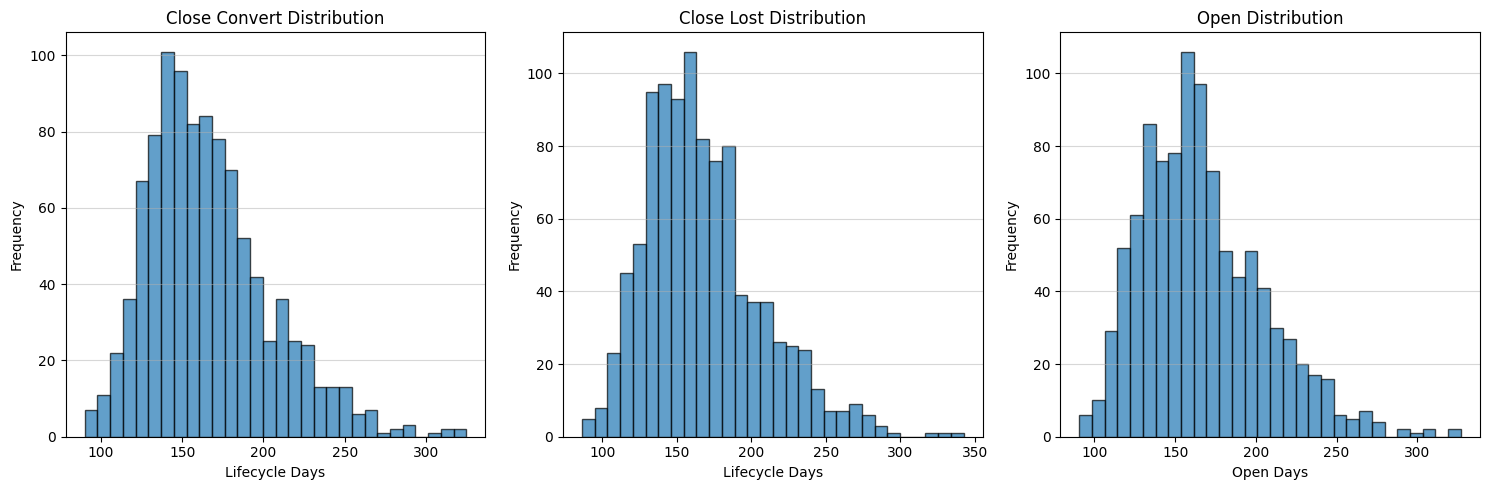

In [97]:
# Simulate lead lifecycle distribution
# Assume similar distribution for all regardless of converted status.
# Converted leads minimum 3 months. All else between 1 and 12.

close_convert_dist = skewnorm.rvs(a=4, loc=120, scale=(60), size=1000)
close_convert_dist = np.clip(close_convert_dist, 90, 365)

close_lost_dist = skewnorm.rvs(a=4, loc=120, scale=(60), size=1000)
close_lost_dist = np.clip(close_lost_dist, 30, 365)

open_dist = skewnorm.rvs(a=4, loc=120, scale=(60), size=1000)
open_dist = np.clip(open_dist, 1, 365)

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# Plot Close Convert Distribution
axes[0].hist(close_convert_dist, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Close Convert Distribution')
axes[0].set_xlabel('Lifecycle Days')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.5)

# Plot Close Lost Distribution
axes[1].hist(close_lost_dist, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Close Lost Distribution')
axes[1].set_xlabel('Lifecycle Days')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.5)

# Plot Open Distribution
axes[2].hist(open_dist, bins=30, edgecolor='black', alpha=0.7)
axes[2].set_title('Open Distribution')
axes[2].set_xlabel('Open Days')
axes[2].set_ylabel('Frequency')
axes[2].grid(axis='y', alpha=0.5)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Show the plot
plt.show()

In [98]:
def simulate_lifecycle(row):
    # Simulate lifecycle in days
    if row['status'] == 'Closed' and row['converted'] == 1:
      days = skewnorm.rvs(a=4, loc=120, scale=(60), size=1)[0]
      days = int(np.clip(days, 90, 365))
      open_date = row['close_date'] - pd.Timedelta(days=days)
    elif row['status'] == 'Closed' and row['converted'] == 0:
      days = skewnorm.rvs(a=4, loc=120, scale=(60), size=1)[0]
      days = int(np.clip(days, 30, 365))
      open_date = row['close_date'] - pd.Timedelta(days=days)
    else: # status == 'Open'
      days = skewnorm.rvs(a=4, loc=120, scale=(60), size=1)[0]
      days = int(np.clip(days, 1, 365))
      open_date = present_date - pd.Timedelta(days=days)

    return open_date

In [99]:
np.random.seed(86)
df_leads['open_date'] = df_leads.apply(simulate_lifecycle, axis=1)
# Reorder last 2 colunms
cols = df_leads.columns[:-2].tolist() + ['open_date', 'close_date']
df_leads = df_leads[cols]

df_leads

,id,company_name,industry,mock_source,status,converted,open_date,close_date
0,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19
1,ACC0010,Bankwell,Banking (Commercial Bank),customer,Closed,1.0,2024-04-29,2024-09-13
2,ACC0037,Simpson Strong-Tie,Manufacturing (Construction Connectors),customer,Closed,1.0,2024-09-17,2025-02-07
3,ACC0046,Kelvion,Manufacturing (Heat Exchangers),customer,Closed,1.0,2024-04-05,2024-10-07
4,ACC0055,ARIA S.p.A. Azienda Regionale per l'Innovazion...,Public Sector (Regional Purchasing & Innovation),customer,Closed,1.0,2024-11-26,2025-03-11
...,...,...,...,...,...,...,...,...
401,ACC0401,Lowe's,Retail (Home Improvement),similar,Closed,0.0,2024-11-09,2025-04-13
402,ACC0402,Quest Diagnostics,Healthcare (Diagnostic Testing),topglobal,Closed,1.0,2024-08-06,2024-12-19
403,ACC0403,Danone,Food & Beverage,topglobal,Closed,0.0,2024-02-23,2024-06-16
404,ACC0404,Semen Indonesia,Manufacturing (Cement),topglobal,Closed,1.0,2024-03-04,2024-08-07


## Visualize Timeline

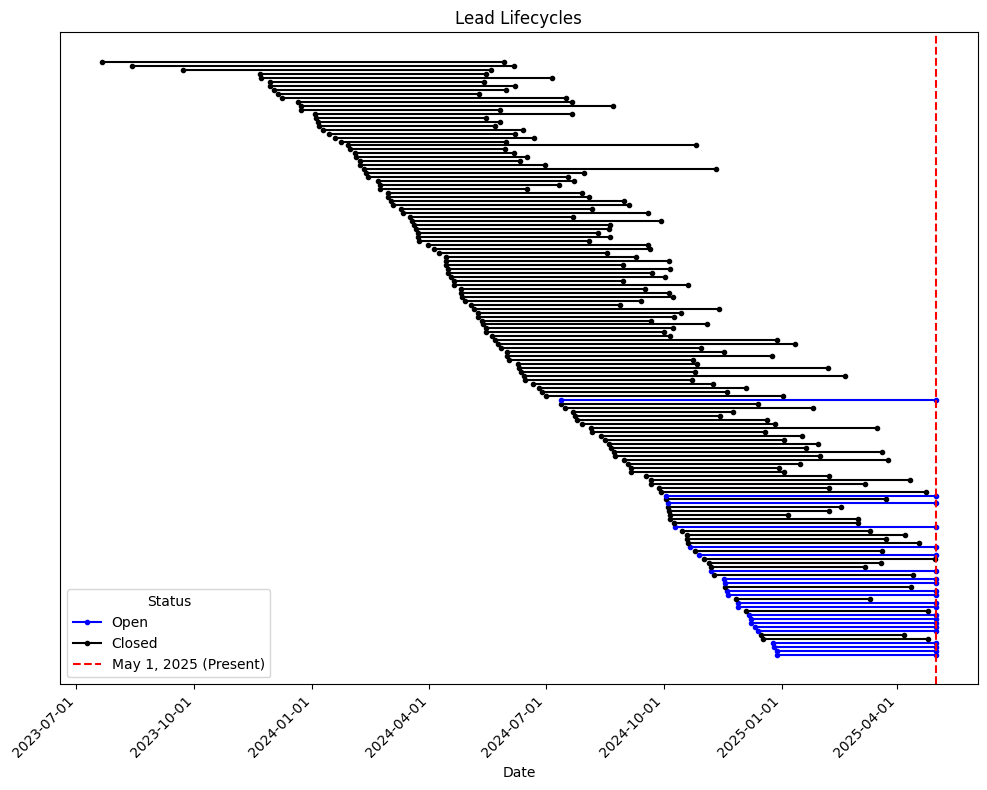

In [103]:
# Set temporary close date for visualization
df_leads_temp = df_leads.copy()
df_leads_temp = df_leads_temp.sample(n=150, random_state=54) # Sample for readability
df_leads_temp['close_date'] = df_leads_temp['close_date'].fillna(present_date)    # Temporary close date for now
df_leads_temp = df_leads_temp.sort_values(by='open_date', ascending=False).reset_index(drop=True)   # Sort by Open Date


colors = {'Open': 'blue', 'Closed': 'black'}

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the open and close dates as lines
for index, row in df_leads_temp.iterrows():
    open_date = row['open_date']
    close_date = row['close_date']
    status = row['status']
    color = colors.get(status, 'orange')  # Default to blue if status not in colors

    # Plot a line segment from Open Date to Close Date
    ax.plot([open_date, close_date], [index, index], marker='o', markersize=3, linestyle='-', color=color, label=status)

# Add a vertical line at 2025-05-01
vertical_date = pd.to_datetime('2025-05-01')
ax.axvline(vertical_date, color='red', linestyle='--', label='May 1, 2025 (Present)')

# Set x-axis label and format
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

# Remove y-axis ticks and labels
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel(None)  # Optional: Remove the y-axis label entirely

# Set title
plt.title('Lead Lifecycles')

# Add legend (only show one label per status)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title='Status')

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Show the plot
plt.show()

# Customer Profile

## Assign favorability

In [161]:
# Assign Favorability Score
def get_favorability(row):

    if row['status'] == 'Closed' and row['converted'] == 1:
        favorability = np.random.randint(70, 101)  # Favorable score estimate
    elif row['status'] == 'Closed' and row['converted'] == 0:
        favorability = np.random.randint(0, 91)  # Unfavorable score estimate
    elif row['status'] == 'Open':
        favorability = np.random.randint(0, 101)  # Broad favorability estimate

    return favorability


df_leads['favorability'] = df_leads.apply(get_favorability, axis=1)

<ipython-input-161-e8a1adcdb639>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_leads['favorability'] = df_leads.apply(get_favorability, axis=1)


Shopping behavior. Company Cyber Defense investment low, medium, or high. High investment means they are well-aware and budgeting for cyber defense. Also consider the degree of cyber resilience current business. If in business, when is renewal date?

In [172]:
def assign_investment_level(row):
    favorability = row['favorability']
    # investment mapping
    mapping = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

    if favorability < 20:
        p = [0.5, 0.3, 0.2, 0.0]
    elif favorability < 50:
        p = [0.3, 0.4, 0.2, 0.1]
    elif favorability < 70:
        p = [0.1, 0.4, 0.4, 0.1]
    elif favorability < 85:
        p = [0.0, 0.3, 0.4, 0.3]
    else:  # favorability >= 85
        p = [0.0, 0.1, 0.4, 0.5]

    # Select investment level from appropriate distribution
    investment_num = np.random.choice([1, 2, 3, 4], p=p)

    return mapping[investment_num]


df_leads['cyber_investment'] = df_leads.apply(assign_investment_level, axis=1)

<ipython-input-172-2af9b748a22e>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_leads['cyber_investment'] = df_leads.apply(assign_investment_level, axis=1)


In [173]:
df_leads

,id,company_name,industry,mock_source,status,converted,open_date,close_date,favorability,cyber_investment
0,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,Very High
1,ACC0010,Bankwell,Banking (Commercial Bank),customer,Closed,1.0,2024-04-29,2024-09-13,94,Very High
2,ACC0037,Simpson Strong-Tie,Manufacturing (Construction Connectors),customer,Closed,1.0,2024-09-17,2025-02-07,94,Very High
3,ACC0046,Kelvion,Manufacturing (Heat Exchangers),customer,Closed,1.0,2024-04-05,2024-10-07,91,High
4,ACC0055,ARIA S.p.A. Azienda Regionale per l'Innovazion...,Public Sector (Regional Purchasing & Innovation),customer,Closed,1.0,2024-11-26,2025-03-11,76,Very High
...,...,...,...,...,...,...,...,...,...,...
401,ACC0401,Lowe's,Retail (Home Improvement),similar,Closed,0.0,2024-11-09,2025-04-13,81,High
402,ACC0402,Quest Diagnostics,Healthcare (Diagnostic Testing),topglobal,Closed,1.0,2024-08-06,2024-12-19,81,Medium
403,ACC0403,Danone,Food & Beverage,topglobal,Closed,0.0,2024-02-23,2024-06-16,37,Low
404,ACC0404,Semen Indonesia,Manufacturing (Cement),topglobal,Closed,1.0,2024-03-04,2024-08-07,90,Very High


In [ ]:
# Definitely graph the representation/distribution of lifecycle spans
I will also need to simulate which companies have competitors, or don't have. Or have a solution, are growing fast and looking for a solution, or not. Or when renewal dates are. Try not to make the data too sparse, you dont have THAT much data to work with.

# Snapshots

Snapshot every 2 or 4 weeks from open date, and final snapshot at close date if applicable.

For all closed leads, first snapshot is Prospecting, last snapshot is Convert or Lost.

Between can be any of the stages from prospecting to negotiation, but must follow that order. Converted leads should be more likely to reach the later stages sooner, whereas lost leads should not, and may not make it far at all.


In [163]:
def create_snapshots(row):
    """Creates bi-weekly snapshots for a given lead."""
    snapshots = []

    # Assign snapshot bounds
    start_date = row['open_date']
    if row['status'] == 'Closed':
        end_date = row['close_date']
    else: end_date = present_date   # Assign present date as proxy close date if lead is open

    snapshot_date = row['open_date']
    snapshot_seq = 1
    while snapshot_date < end_date:
        # Create a dict of the row to represent a snapshot
        snapshot = row.to_dict()
        # Add date and sequence number
        snapshot['snapshot_date'] = snapshot_date
        snapshot['snapshot_seq'] = snapshot_seq

        if snapshot_date == start_date:   # Snapshot on open date
            snapshot['lead_stage'] = 'Prospecting'
        elif start_date < snapshot_date < end_date:    # Snapshot between open and close date
            snapshot['lead_stage'] = None

        # Add snapshot to list
        snapshots.append(snapshot)
        # Increment
        snapshot_date += pd.DateOffset(weeks=2)
        snapshot_seq += 1

    # Add snapshot for close date (Not technically a lead anymore if closed date)
    snapshot = row.to_dict()
    snapshot['snapshot_date'] = row['close_date']
    snapshot['snapshot_seq'] = snapshot_seq
    # Determined if lead is closed, None if open
    if row['status'] == 'Closed' and row['converted'] == 1:
      snapshot['lead_stage'] = 'Converted'
    elif row['status'] == 'Closed' and row['converted'] == 0:
      snapshot['lead_stage'] = 'Lost'
    else: # status is Open
      snapshot['lead_stage'] = None

    # Add snapshot to list
    snapshots.append(snapshot)

    return snapshots

## Simulate Pipeline Progression

In [165]:
pipeline_stages = ['Prospecting', 'Qualified', 'Proposal', 'Negotiation', 'Converted/Lost']

def simulate_pipeline_progression(snapshots):
    """Takes in snapshots for one lead and assigns lead stages over time."""
    n_snapshots = len(snapshots)    # Count of snapshots
    # Get lead results
    lead_status = snapshots[0]['status']
    lead_converted = snapshots[0]['converted']
    favorability = snapshots[0]['favorability']

    if lead_status == 'Closed' and lead_converted == 1:
        # favorability = np.random.randint(70, 101)  # Favorable score estimate
        stages = pipeline_stages  # Progress through all stages

    elif lead_status == 'Closed' and lead_converted == 0:
        # favorability = np.random.randint(0, 91)  # Unfavorable score estimate
        max_stage_idx = np.searchsorted([20, 50, 70, 85], favorability, side='right')
        stages = pipeline_stages[:max_stage_idx + 1] # May not progress through all stages

    elif lead_status == 'Open':
        # favorability = np.random.randint(0, 101)  # Broad favorability estimate
        max_stage_idx = np.searchsorted([20, 50, 70, 85], favorability, side='right')
        stages = pipeline_stages[:max_stage_idx + 1] # Never reach Converted/Lost determination. Remove closed stage if present

    # Now assign stages evenly across snapshots
    stage_per_snapshot = []
    stages = [s for s in stages if s != 'Converted/Lost'] # Remove closed stage if present, add only on final
    n_stages = len(stages)
    for idx, snapshot in enumerate(snapshots):
        is_final = (idx == n_snapshots - 1)  # Check if last snapshot
        snapshot = snapshot.copy()  # Copy row

        if is_final and lead_status == 'Closed' and snapshot['converted'] == 1:
            snapshot['lead_stage'] = 'Converted' # Only on the last snapshot
        elif is_final and lead_status == 'Closed' and snapshot['converted'] == 0:
            snapshot['lead_stage'] = 'Lost' # Only on the last snapshot
        else:
            stage_idx = min(idx * n_stages // (n_snapshots - 1), n_stages - 1)
            snapshot['lead_stage'] = stages[stage_idx]

        stage_per_snapshot.append(snapshot)

    return stage_per_snapshot

In [166]:
all_snapshots = []
for idx, row in df_leads.iterrows():
    lead_snapshots = create_snapshots(row)
    simulated_snapshots = simulate_pipeline_progression(lead_snapshots)
    all_snapshots.extend(simulated_snapshots)

df_snapshots = pd.DataFrame(all_snapshots)
df_snapshots

,id,company_name,industry,mock_source,status,converted,open_date,close_date,favorability,snapshot_date,snapshot_seq,lead_stage
0,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,2024-03-09,1,Prospecting
1,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,2024-03-23,2,Prospecting
2,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,2024-04-06,3,Prospecting
3,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,2024-04-20,4,Qualified
4,ACC0002,St Luke's,Healthcare (Hospital Network),customer,Closed,1.0,2024-03-09,2024-08-19,90,2024-05-04,5,Qualified
...,...,...,...,...,...,...,...,...,...,...,...,...
5332,ACC0405,Vietin Bank,Banking,topglobal,Closed,0.0,2024-11-07,2025-02-22,38,2025-01-02,5,Qualified
5333,ACC0405,Vietin Bank,Banking,topglobal,Closed,0.0,2024-11-07,2025-02-22,38,2025-01-16,6,Qualified
5334,ACC0405,Vietin Bank,Banking,topglobal,Closed,0.0,2024-11-07,2025-02-22,38,2025-01-30,7,Qualified
5335,ACC0405,Vietin Bank,Banking,topglobal,Closed,0.0,2024-11-07,2025-02-22,38,2025-02-13,8,Qualified


## Visualize Pipeline

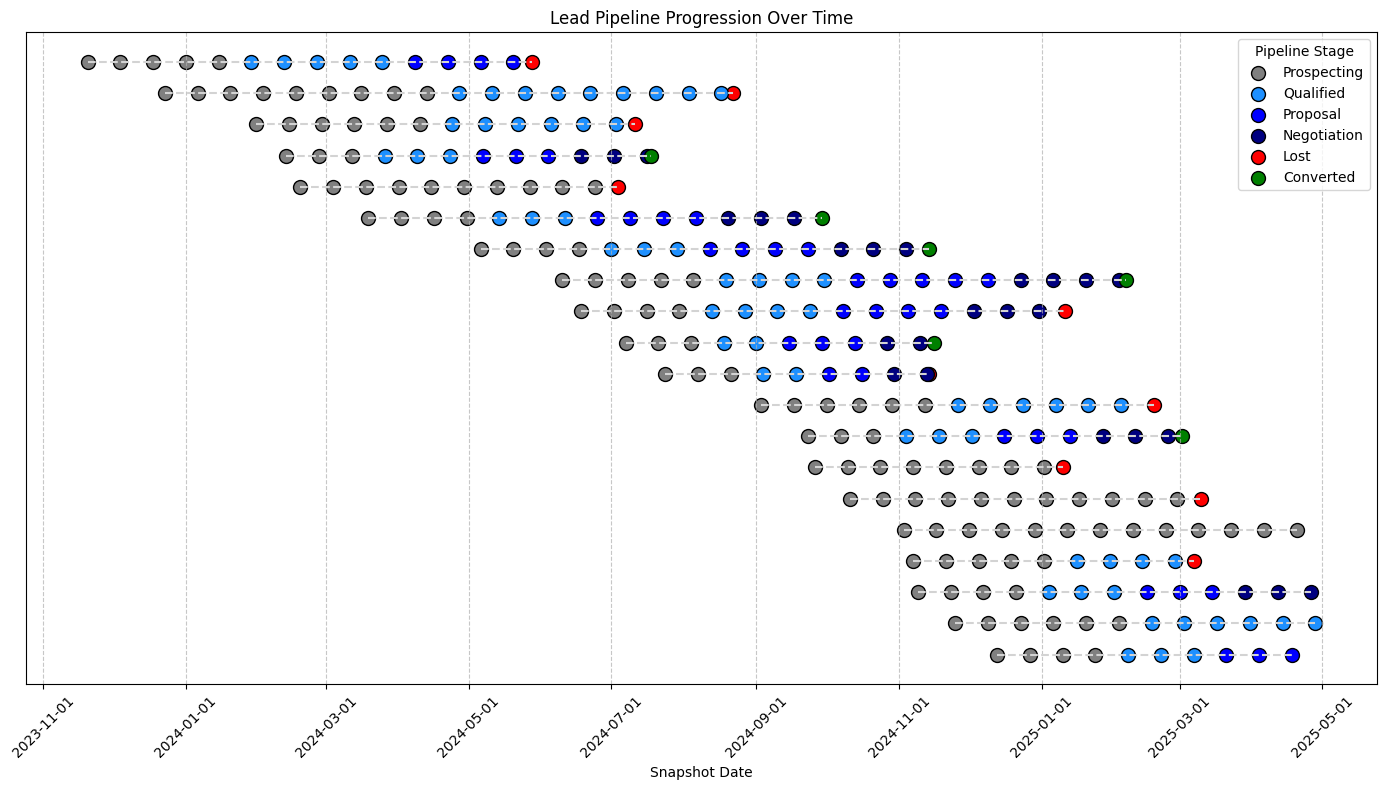

In [169]:
# Sample 100 random unique leads
sampled_leads = df_snapshots['id'].drop_duplicates().sample(n=20, random_state=42)
# Filter the snapshots to just these leads
df_snapshots_temp = df_snapshots[df_snapshots['id'].isin(sampled_leads)]
# Sort by date
df_snapshots_temp = df_snapshots_temp.sort_values(by='open_date', ascending=False).reset_index(drop=True)

# Example stage -> color mapping
stage_colors = {
    'Prospecting': 'gray',
    'Qualified': 'dodgerblue',
    'Proposal': 'blue',
    'Negotiation': 'navy',
    'Converted': 'green',
    'Lost': 'red',
    }

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Ensure snapshot_date is datetime
df_snapshots_temp['snapshot_date'] = pd.to_datetime(df_snapshots_temp['snapshot_date'])

# Get unique leads
leads = df_snapshots_temp['id'].unique()

# Map each lead to a y-position
lead_y_positions = {lead: i for i, lead in enumerate(leads)}

# Plot each snapshot
for _, row in df_snapshots_temp.iterrows():
    lead_id = row['id']
    x = row['snapshot_date']
    y = lead_y_positions[lead_id]
    stage = row['lead_stage']
    color = stage_colors.get(stage, 'black')  # fallback to black if missing

    ax.scatter(x, y, color=color, label=stage, s=100, edgecolor='k')

# Draw a horizontal line for each lead
for lead_id, y in lead_y_positions.items():
    lead_snapshots = df_snapshots_temp[df_snapshots_temp['id'] == lead_id]
    min_date = lead_snapshots['snapshot_date'].min()
    max_date = lead_snapshots['snapshot_date'].max()
    ax.plot([min_date, max_date], [y, y], color='lightgray', linestyle='--')

# Formatting
ax.set_xlabel('Snapshot Date')
ax.set_title('Lead Pipeline Progression Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Remove y-axis ticks and labels
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel(None)  # Optional: Remove the y-axis label entirely

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Pipeline Stage')

plt.tight_layout()
plt.show()

Next steps. Maybe randomize the general rules for how far each lead type progresses?
- 100% of closed converted reach negotiation
- 20% of closed lost reach negotiation, 40% reach proposal, 60% reach qualification

Simple solution. Just set a % chance that stage progresses with some advance-must constraints.
Closed convert have a higher % chance of advancing. Closed lost have a lower % chance of advancing. Just use a single flat % for simplicity. If later on, you feel this is not sufficient, you could also map out a must-constraint, where a closed convert MUST advance after a number of stages or a portion of way through lifecycle.
I'm just thinking of how I can use the same logic across closed and open leads. % advance is simple but may run into issues since each lead as different lifecycle times. Another option is by % of way through. In that case, identify how far each lead goes by end of lifecycle. Then identify random points of advancement, such that it ends at the right place.


## Simulate Engagement and Shopping Behavior

## Summary
Should summarize the state of the lead in the snapshot. Also, if it is a historical lead, the resulting 'why' of whether it converted, or lost (in negotiation or aged out etc) should be explained. Have GPT take a look at the overall account and make up some plausible reason. This could be useful for GPT in providing explanations.

# Create Mock Lead List

In [ ]:
[
  {
    "account_id": "ACC001",
    "account_name": "Acme Corp",
    "industry": "Technology",
    "revenue": 15000000,
    "employee_count": 250,
    "deal_stage": "Proposal",
    "deal_value": 50000,
    "days_in_current_stage": 15,
    "last_activity_date": "2025-04-22",
    "engagement_score": 85,
    "email_interactions": 22,
    "events_attended": ["Webinar A", "Industry Conference"],
    "content_downloads": ["Case Study X", "Solution Brief Y", "Pricing Guide Z"],
    "intent_signals": ["competitor analysis", "crm integration"],
    "renewal_date": "2025-07-15"
  },
  {
    "account_id": "ACC002",
    "account_name": "Beta Industries",
    "industry": "Manufacturing",
    "revenue": 50000000,
    "employee_count": 500,
    "deal_stage": "Qualification",
    "deal_value": 120000,
    "days_in_current_stage": 5,
    "last_activity_date": "2025-04-23",
    "engagement_score": 60,
    "email_interactions": 8,
    "events_attended": ["Webinar A"],
    "content_downloads": ["Product Overview"],
    "intent_signals": ["supply chain optimization"],
    "renewal_date": null
  },
  {
    "account_id": "ACC003",
    "account_name": "Gamma Solutions",
    "industry": "Software",
    "revenue": 8000000,
    "employee_count": 100,
    "deal_stage": "Negotiation",
    "deal_value": 35000,
    "days_in_current_stage": 25,
    "last_activity_date": "2025-04-18",
    "engagement_score": 92,
    "email_interactions": 35,
    "events_attended": ["Industry Conference"],
    "content_downloads": ["Case Study X", "Demo Recording"],
    "intent_signals": ["contract terms", "implementation timeline"],
    "renewal_date": "2025-05-30"
  },
  {
    "account_id": "ACC004",
    "account_name": "Delta Group",
    "industry": "Finance",
    "revenue": 200000000,
    "employee_count": 1500,
    "deal_stage": "Qualification",
    "deal_value": 250000,
    "days_in_current_stage": 2,
    "last_activity_date": "2025-04-24",
    "engagement_score": 45,
    "email_interactions": 3,
    "events_attended": [],
    "content_downloads": ["Whitepaper Z"],
    "intent_signals": ["regulatory compliance software"],
    "renewal_date": null
  },
  {
    "account_id": "ACC005",
    "account_name": "Epsilon Systems",
    "industry": "Technology",
    "revenue": 5000000,
    "employee_count": 75,
    "deal_stage": "Proposal",
    "deal_value": 15000,
    "days_in_current_stage": 8,
    "last_activity_date": "2025-04-21",
    "engagement_score": 70,
    "email_interactions": 15,
    "events_attended": ["Webinar B"],
    "content_downloads": ["Solution Brief Y"],
    "intent_signals": ["feature comparison"],
    "renewal_date": "2025-09-10"
  }
]